# Cross validation

Cross validation is a powerful technique to evaluate the performance of a model on unseen data. In this example, we will showcase the different cross validation methods available in PortfolioOptimisers.jl and how to use them to evaluate the performance of our portfolio optimization models.

Cross validation can be used as a standalone method to evaluate the performance of a model, or it can be used in conjunction with other techniques like hyperparameter tuning or model selection. They can also be used in `NestedClustered` and `Stacking` optimisation estimators to optimise the outer estimator on the out-of-sample performance of the inner estimators.

This example will only focus on showcasing the different cross validation methods, with examples on how to use them and what metrics can be computed. We also demonstrate the plotting functions available for cross-validation results.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
tsfmt = (v, i, j) -> begin
    if j == 1
        return Date(v)
    else
        return v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Setting up

For this example, we will use 5 years of daily data. This is so that we have enough data to perform cross validation on significant amounts of data for both training and testing.

Cross validation cannot have precomputed values like we have done in previous examples. This is because the training and testing sets are generated on the fly, and the performance metrics are computed based on the results of the optimization on these sets.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel, Statistics

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252 * 5):end]
pretty_table(X[(end - 5):end]; formatters = [tsfmt])

# Compute the returns
rd = prices_to_returns(X)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel4, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.85),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel5, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.8),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel6, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.75),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel7, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.70),
              check_sol = (; allow_local = true, allow_almost = true))];

┌────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────
│  timestamp │    AAPL │     AMD │     BAC │     BBY │     CVX │      GE │     ⋯
│       Date │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Flo ⋯
├────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼──────
│ 2022-12-20 │ 131.916 │   65.05 │  31.729 │  77.371 │ 169.497 │  62.604 │ 310 ⋯
│ 2022-12-21 │ 135.057 │   67.68 │  32.212 │  78.729 │  171.49 │   64.67 │ 314 ⋯
│ 2022-12-22 │ 131.846 │   63.86 │  31.927 │  78.563 │ 168.918 │  63.727 │ 311 ⋯
│ 2022-12-23 │ 131.477 │   64.52 │  32.005 │  79.432 │  174.14 │  63.742 │ 314 ⋯
│ 2022-12-27 │ 129.652 │   63.27 │  32.065 │   79.93 │ 176.329 │  64.561 │ 314 ⋯
│ 2022-12-28 │ 125.674 │   62.57 │  32.301 │  78.279 │ 173.728 │  63.883 │  31 ⋯
└────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────
                                                              14 columns omitted


For this tutorial we will use the basic `MeanRisk` estimator, but the cross validation works for all optimisation estimators, even when computing pareto fronts.

In [3]:
mr = MeanRisk(; opt = JuMPOptimiser(; slv = slv))

MeanRisk
  opt ┼ JuMPOptimiser
      │        pe ┼ EmpiricalPrior
      │           │        ce ┼ PortfolioOptimisersCovariance
      │           │           │   ce ┼ Covariance
      │           │           │      │    me ┼ SimpleExpectedReturns
      │           │           │      │       │   w ┴ nothing
      │           │           │      │    ce ┼ GeneralCovariance
      │           │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
      │           │           │      │       │    w ┴ nothing
      │           │           │      │   alg ┴ FullMoment()
      │           │           │   mp ┼ MatrixProcessing
      │           │           │      │     pdm ┼ Posdef
      │           │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
      │           │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
      │           │           │      │      dn ┼ nothing
      │           │           │      │      dt ┼ no

## 2. Cross validation
### 2.1 KFold

The simplest form of cross validation is KFold. This method splits the data into K folds, and then iteratively trains on K-1 folds and tests on the remaining fold. This process is repeated K times, with each fold being used as the test set once.

The `KFold` indices can be generated independently of the optimisation. Let's say we want to perform 5-fold cross validation, this works out to be roughly one per year.

In [4]:
kfold = KFold(; n = 5)

KFold
             n ┼ Int64: 5
   purged_size ┼ Int64: 0
  embargo_size ┴ Int64: 0


For demonstration purposes we can generate the splits using the `split` method. This is not necessary as the cross validation will generate them internally.

In [5]:
kfold_res = split(kfold, rd)

show(kfold_res.train_idx)
show(kfold_res.test_idx)

[[253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452

Let's perform the cross validation.

In [6]:
kfold_pred = cross_val_predict(mr, rd, kfold)

MultiPeriodPredictionResult
  pred ┼ 5-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 1260-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 1260-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


We can visualise the out-of-sample performance and weight behaviour across folds.

Portfolio cumulative returns across all KFold test periods.

In [7]:
using StatsPlots, GraphRecipes

Per-asset weight distribution across folds.

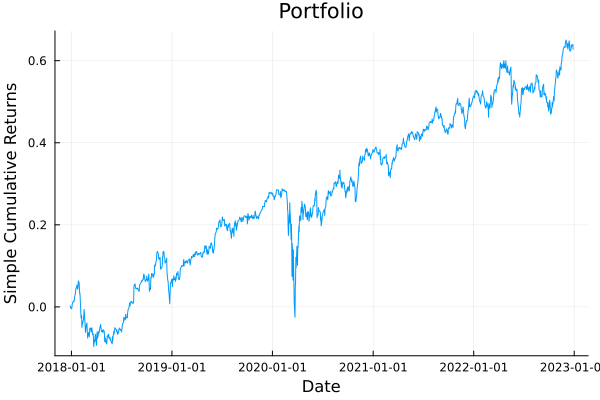

In [8]:
plot_ptf_cumulative_returns(kfold_pred)

Portfolio turnover between consecutive folds.

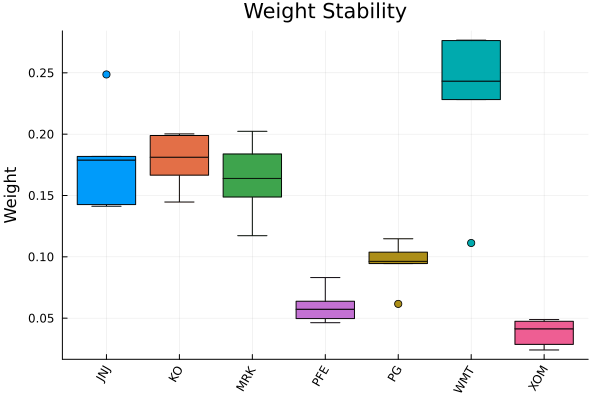

In [9]:
plot_weight_stability(kfold_pred)

Cross-validation scores (second moment / variance) per fold.

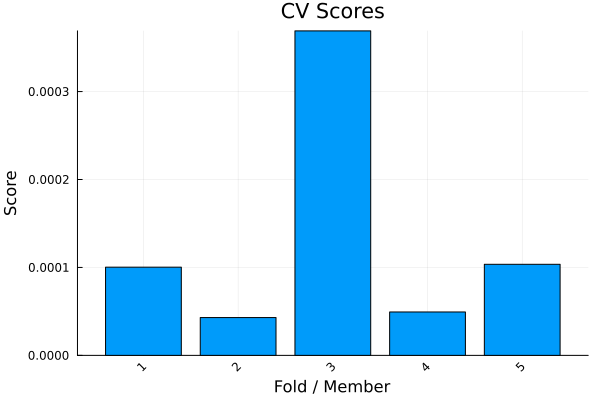

In [10]:
plot_turnover(kfold_pred)
plot_cv_scores(LowOrderMoment(; alg = SecondMoment()), kfold_pred)

The result is a `MultiPeriodPredictionResult` object, which is a wrapper for a vector of `PredictionResult` objects, one for each fold. Each `PredictionResult` contains the optimisation result based on the training set, and a `PredictionReturnsResult` containing the predicted returns result of the optimised portfolio evaluated on its corresponding test set.

We can individually access the result of each fold by indexing into the `pred` field of the `MultiPeriodPredictionResult` object, but we can also directly access via the accessing the `mrd` and `mres` properties, which stand for multi-rd and multi-res. `mrd` concatenates the predicted returns into a single `PredictionReturnsResult`. Since the embargo and purged sizes are zero, the timestamps of the predicted returns should be the same as the timestamps of the original returns result.

In [11]:
println("isequal(kfold_pred.mrd.ts, rd.ts) = $(isequal(kfold_pred.mrd.ts, rd.ts))")

isequal(kfold_pred.mrd.ts, rd.ts) = true


We can also compute performance metrics (risk measures) on the predicted returns. However, we can only use risk measures that use the returns series as an input. This means `StandardDeviation`, `NegativeSkewness`, `TurnoverRiskMeasure`, `TrackingRiskMeasure` with `WeightsTracking`, `Variance`, `UncertaintySetVariance`, `EqualRisk`, `ExpectedReturn` and `ExpectedReturnRiskRatio`, as well as any risk measure that uses any of these cannot be used. But there are ways around this, for example:

- For the variance and standard deviation, we can use `LowOrderMoment` with the appropriate algorithms.
- For `NegativeSkewness` we can use `HighOrderMoment`, or `Skewness`.
- For `ExpectedReturn` and `ExpectedReturnRiskRatio` we can use `MeanReturn` and `MeanReturnRiskRatio` respectively.

Here we will compute the variance.

In [12]:
println("KFold(5) prediction variance = $(expected_risk(LowOrderMoment(; alg = SecondMoment()), kfold_pred))")

KFold(5) prediction variance = 0.00013266913989921168


### 2.2 Combinatorial

The `CombinatorialCrossValidation` method generates all possible combinations of the data into training and testing sets. This method is computationally expensive, but provides a more comprehensive evaluation of the model's performance on unseen data.

There is also a way to compute the optimal number of folds and training folds given a user-defined desired training and test set lengths, as well as the relative weight between the training size and number of test paths.

In [13]:
T = size(rd.X, 1)
target_train_size = 200
target_test_size = 70
n_folds, n_test_folds = optimal_number_folds(T, target_train_size, target_test_size)
cfold = CombinatorialCrossValidation(; n_folds = n_folds, n_test_folds = n_test_folds)

CombinatorialCrossValidation
       n_folds ┼ Int64: 13
  n_test_folds ┼ Int64: 11
   purged_size ┼ Int64: 0
  embargo_size ┴ Int64: 0


Let's see the indices this produces.

In [14]:
cfold_res = split(cfold, rd)

CombinatorialCrossValidationResult
  train_idx ┼ 78-element Vector{Vector{Int64}}
   test_idx ┼ 78-element Vector{Vector{Vector{Int64}}}
   path_ids ┴ 11×78 Matrix{Int64}


Here we have 78 splits, each testing path split into 11 folds. This means we have 78 * 11 = 858 total folds, which is a significant increase from the 5 folds we had in KFold. This is the trade-off for having a more comprehensive evaluation of the model's performance on unseen data.

But it also means we need a way to find a good representative of the predictions in order to evaluate the out of sample performance. First let's perform the cross validation.

There is some nuance with this approach in that the splits do not represent the same number of paths, in fact there are only 66 unique paths, which can be seen from `cfold_res.path_ids`.

In [15]:
cfold_res.path_ids

11×78 Matrix{Int64}:
 1  2  3  4  5  6  7  8  9  10  11  12  …  59  60  61  62  63  64  65  66  66
 1  2  3  4  5  6  7  8  9  10  11  12     59  60  61  62  63  64  65  65  66
 1  2  3  4  5  6  7  8  9  10  11  12     59  60  61  62  63  64  64  65  66
 1  2  3  4  5  6  7  8  9  10  11  12     59  60  61  62  63  63  64  65  66
 1  2  3  4  5  6  7  8  9  10  11  12     59  60  61  62  62  63  64  65  66
 1  2  3  4  5  6  7  8  9  10  11  12  …  59  60  61  61  62  63  64  65  66
 1  2  3  4  5  6  7  8  9  10  11  12     59  60  60  61  62  63  64  65  66
 1  2  3  4  5  6  7  8  9  10   7   8     59  59  60  61  62  63  64  65  66
 1  2  3  4  5  6  4  5  6   6   7   8     58  59  60  61  62  63  64  65  66
 1  2  3  2  3  3  4  5  5   6   7   8     58  59  60  61  62  63  64  65  66
 1  1  1  2  2  3  4  4  5   6   7   7  …  58  59  60  61  62  63  64  65  66

We can now perform the cross validation.

In [16]:
cfold_pred = cross_val_predict(mr, rd, cfold)

PopulationPredictionResult
  pred ┼ 66-element Vector{MultiPeriodPredictionResult}
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriodPredictionResult ⋯
       │ MultiPeriod

We can see that there are indeed 66 predictions. Each is a valid representative of the out-of-sample performance of the model. However, for evaluating the performance, we can use a sample or the median of the predictions. The median is a good representative of the performance, as it is not affected by outliers, and it is a good measure of central tendency. We can do this with custom function, or a functor of a subtype of `PredictionScorer`. We've implemented a simple one called `NearestQuantilePrediction` which takes the prediction with the nearest quantile to the desired quantile of the distribution of predictions, it defaults to the median.

We will use the risk return ratio of the variance as our performance metric. The paths are sorted according to their expected risk, return based risk measures sort them based on descending order, while true risk measures sort them in ascending order.

In [17]:
sharpe_scorer = NearestQuantilePrediction(;
                                          r = MeanReturnRiskRatio(;
                                                                  rk = LowOrderMoment(;
                                                                                      alg = SecondMoment())))

NearestQuantilePrediction
         r ┼ MeanReturnRiskRatio
           │   rt ┼ MeanReturn
           │      │      w ┼ nothing
           │      │   flag ┴ Bool: false
           │   rk ┼ LowOrderMoment
           │      │   settings ┼ RiskMeasureSettings
           │      │            │   scale ┼ Float64: 1.0
           │      │            │      ub ┼ nothing
           │      │            │     rke ┴ Bool: true
           │      │          w ┼ nothing
           │      │         mu ┼ nothing
           │      │        alg ┼ SecondMoment
           │      │            │     ve ┼ SimpleVariance
           │      │            │        │          me ┼ nothing
           │      │            │        │           w ┼ nothing
           │      │            │        │   corrected ┴ Bool: true
           │      │            │   alg1 ┼ FullMoment()
           │      │            │   alg2 ┴ SquaredSOCRiskExpr()
           │   rf ┴ Float64: 0.0
         q ┼ Float64: 0.5
  r_kwargs ┼ @NamedTuple{}

Scorer is a functor which takes a population as an input and outputs a tuple of the single prediction and the index in the population which matches the desired quantile of the distribution of predictions. In this case, we are using the mean return risk ratio with the variance as the risk measure, and we are looking for the prediction with the nearest quantile to 0.5, which is the median.

In [18]:
median_pred_max_sharpe = sharpe_scorer(cfold_pred)

MultiPeriodPredictionResult
  pred ┼ 13-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 1260-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 1260-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ Int64: 18


The prediction `id` corresponds to the index/path id of the prediction in the population.

In [19]:
median_pred_max_sharpe === cfold_pred.pred[median_pred_max_sharpe.id]

true

Similarty to the KFold, the timestamps of the predicted returns should be the same as the timestamps of the original returns result, since the embargo and purged sizes are zero.

In [20]:
isequal(median_pred_max_sharpe.mrd.ts, rd.ts)

true

We can further verify this by computing the risk return ratio of the variance for all predictions and seeing that the prediction with a risk value closest to the median is indeed the same as the one we found with the scorer. Note that the scorer also filters out predictions whose optimisations failed, so in order to be truly rigorous we'd need to skip NaN values in the array of risks, while keeping the indices aligned, but for demonstration purposes this is sufficient.

In [21]:
sharpe_ratios = expected_risk(MeanReturnRiskRatio(;
                                                  rk = LowOrderMoment(;
                                                                      alg = SecondMoment())),
                              cfold_pred)
argmin(abs.(sharpe_ratios .- median(sharpe_ratios))) == median_pred_max_sharpe.id

true

Weight stability across all combinatorial CV paths shows how robust the model is to different
training subsets.

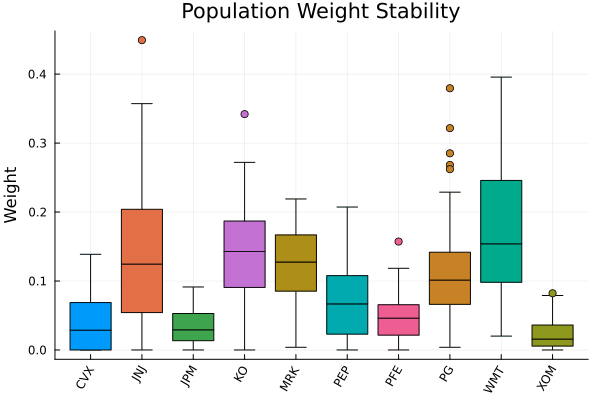

In [22]:
plot_weight_stability(cfold_pred)

CV scores (Sharpe ratio) across all paths — the distribution shows the range of out-of-sample
performance.

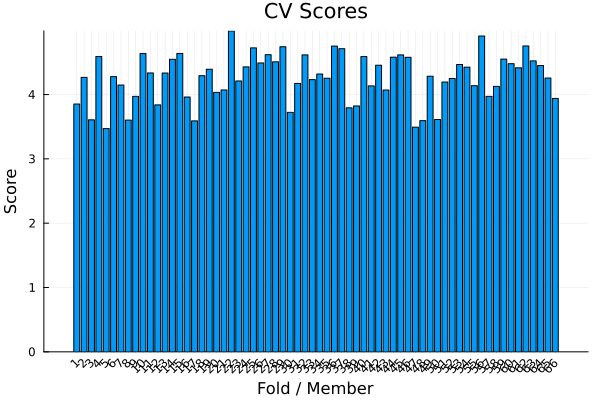

In [23]:
plot_cv_scores(MeanReturnRiskRatio(; rk = LowOrderMoment(; alg = SecondMoment())),
               cfold_pred)

We can choose any compatible risk measure as outlined above, for demonstration purposes we will now rank them based on the variance.

In [24]:
variance_scorer = NearestQuantilePrediction(; r = LowOrderMoment(; alg = SecondMoment()))
median_pred_min_variance = variance_scorer(cfold_pred)

MultiPeriodPredictionResult
  pred ┼ 13-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 1260-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 1260-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ Int64: 18


Again the id matches the prediction with the nearest quantile to the median of the distribution of predictions.

In [25]:
median_pred_min_variance === cfold_pred.pred[median_pred_min_variance.id]

true

As always, the timestamps match.

In [26]:
isequal(median_pred_min_variance.mrd.ts, rd.ts)

true

### 2.3 WalkForward

We offer two different walkforward estimators, `IndexWalkForward` and `DateWalkForward`. The former splits the data based on the number of observations, while the latter splits the data based on the timestamps, and can be used with Julia's `Dates` module to adjust periods to specific times.

The walkforward method is a more realistic evaluation of the model's performance on unseen data, as it mimics the way the model would be used in practice. It can also dynamically use the previous optimisation weights in constraints and risk measures if so desired.

#### 2.3.1 IndexWalkForward

The simpler estimator is `IndexWalkForward` so we will start with this one. We will use training sets of one full year and test sets of 3 months. Note that a year has roughly 252 trading days. We will again not use any purging, meaning that the test set will immediately follow the training set, and there will be no gap between them. This means that the timestamps of the predicted returns should be the same as the timestamps of the original returns result minus the first 252 entries.

In [27]:
idx_walk_forward = IndexWalkForward(252, round(Int, 252 / 4))
idx_walk_forward_res = split(idx_walk_forward, rd)
show(idx_walk_forward_res.train_idx)
show(idx_walk_forward_res.test_idx)

UnitRange{Int64}[1:252, 64:315, 127:378, 190:441, 253:504, 316:567, 379:630, 442:693, 505:756, 568:819, 631:882, 694:945, 757:1008, 820:1071, 883:1134, 946:1197]UnitRange{Int64}[253:315, 316:378, 379:441, 442:504, 505:567, 568:630, 631:693, 694:756, 757:819, 820:882, 883:945, 946:1008, 1009:1071, 1072:1134, 1135:1197, 1198:1260]

We can generate the prediction now.

In [28]:
idx_walkforward_pred = cross_val_predict(mr, rd, idx_walk_forward)

MultiPeriodPredictionResult
  pred ┼ 16-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 1008-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 1008-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


Let's check the timestamps.

In [29]:
isequal(idx_walkforward_pred.mrd.ts, rd.ts[253:end])

true

Cumulative returns across all walk-forward test windows, stacked together.

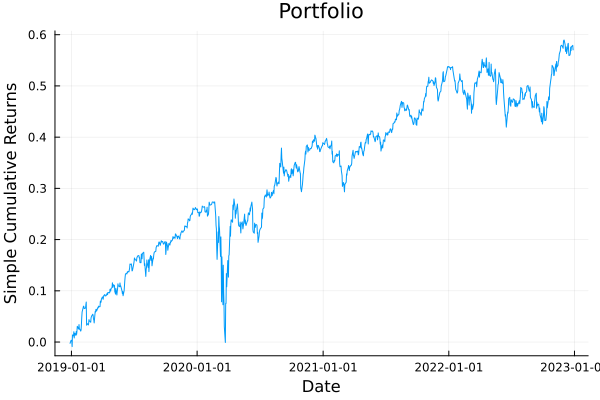

In [30]:
plot_ptf_cumulative_returns(idx_walkforward_pred)

Portfolio composition evolution across walk-forward windows as a stacked bar.

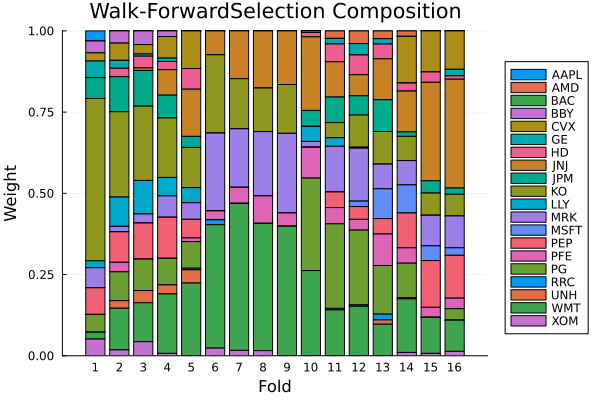

In [31]:
plot_composition(idx_walkforward_pred)

Turnover at each rebalancing point.

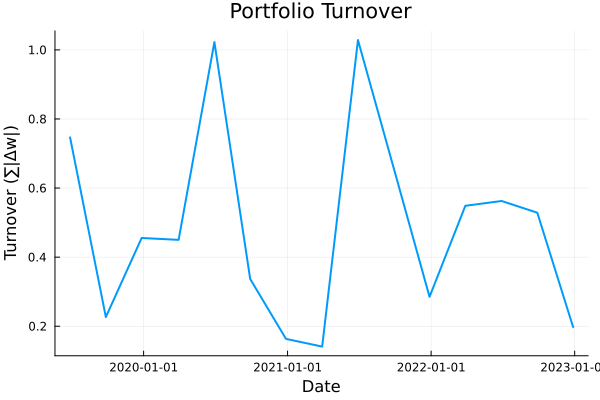

In [32]:
plot_turnover(idx_walkforward_pred)

Now let's see the evolution of the weights across the different splits.

In [33]:
pretty_table(hcat(DataFrame(:tickers => rd.nx),
                  DataFrame(reduce(hcat, getproperty.(idx_walkforward_pred.res, :w)),
                            Symbol.(1:16))); formatters = [resfmt])

┌─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬───
│ tickers │        1 │        2 │        3 │        4 │        5 │        6 │  ⋯
│  String │  Float64 │  Float64 │  Float64 │  Float64 │  Float64 │  Float64 │  ⋯
├─────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼───
│    AAPL │  3.104 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │  ⋯
│     AMD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │  ⋯
│     BAC │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │  ⋯
│     BBY │  3.634 % │  3.773 % │  4.216 % │  1.757 % │    0.0 % │    0.0 % │  ⋯
│     CVX │  2.537 % │  5.289 % │  2.886 % │  6.628 % │ 11.588 % │    0.0 % │  ⋯
│      GE │  5.126 % │  2.433 % │  0.684 % │  1.042 % │    0.0 % │    0.0 % │  ⋯
│      HD │    0.0 % │  2.601 % │  3.602 % │  2.514 % │  6.347 % │    0.0 % │  ⋯
│     JNJ │    0.0 % │  0.017 % │  0.797 % │  7.841 % │ 14.529 % │  7.359 % │  ⋯
│     JPM │  6.409 % │ 10.76

As we can see, the weights can evolve in a fairly volatile manner. We can avoid this by adding a non-fixed turnover constraint, fee, risk measure, or weight based tracking. For demonstration purposes we will use a turnover constraint with a maximum turnover of 2% per period for all assets from an equal weight starting point, we will provide the `Turnover` directly, which is non-fixed by default, meaning it will be updated every period.

In [34]:
N = size(rd.X, 2)
tn = Turnover(; w = range(; start = 1 / N, stop = 1 / N, length = N), val = 0.02)

Turnover
      w ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
    val ┼ Float64: 0.02
  fixed ┴ Bool: false


We can generate the optimiser with the turnover constraint and then perform the walkforward cross validation again.

In [35]:
mr = MeanRisk(; opt = JuMPOptimiser(; slv = slv, tn = tn))
idx_tn_walkforward_pred = cross_val_predict(mr, rd, idx_walk_forward)

┌ Info: Running walk forward sequentially because the optimiser must either use the previous optimisation's weights (needs_previous_weights(opt) == true), and/or is time dependent (is_time_dependent(opt) == false). This is because somewhere within the optimisation estimator is contained at least one of the following:
│ 	- Turnover and/or TurnoverEstimator,
│ 	- WeightsTracking,
│ 	- TurnoverRiskMeasure,
│ 	- custom constraints which use asset weights,
│ 	- custom objective penalties which use asset weights.
│ 	- Or there is a time dependent constraint or objective penalty.
└ To enable parallel processing please either mark the weights as fixed or remove the offending component(s).


MultiPeriodPredictionResult
  pred ┼ 16-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 1008-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 1008-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


Now let's see the evolution of the weights across the different splits. We can see how the weights change at most 2% per period.

In [36]:
pretty_table(hcat(DataFrame(:tickers => rd.nx),
                  DataFrame(reduce(hcat, getproperty.(idx_tn_walkforward_pred.res, :w)),
                            Symbol.(1:16))); formatters = [resfmt])

┌─────────┬─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────
│ tickers │       1 │       2 │       3 │       4 │        5 │        6 │      ⋯
│  String │ Float64 │ Float64 │ Float64 │ Float64 │  Float64 │  Float64 │  Flo ⋯
├─────────┼─────────┼─────────┼─────────┼─────────┼──────────┼──────────┼───────
│    AAPL │   3.0 % │   1.0 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     AMD │   3.0 % │   1.0 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     BAC │   3.0 % │ 1.354 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     BBY │   3.0 % │ 2.903 % │  3.93 % │  1.93 % │    0.0 % │    0.0 % │    0 ⋯
│     CVX │   3.0 % │ 4.681 % │ 3.399 % │ 5.398 % │  7.398 % │  5.398 % │  3.3 ⋯
│      GE │ 4.288 % │ 2.345 % │ 0.808 % │ 0.718 % │    0.0 % │    0.0 % │    0 ⋯
│      HD │   3.0 % │   5.0 % │ 5.948 % │ 3.948 % │  5.947 % │  3.947 % │  1.9 ⋯
│     JNJ │   7.0 % │ 5.987 % │ 4.334 % │ 6.334 % │  8.333 % │ 10.333 % │ 12.3 ⋯
│     JPM │ 5.712 % │ 7.712 

With the turnover constraint the turnover per rebalancing period is now capped at 2%.

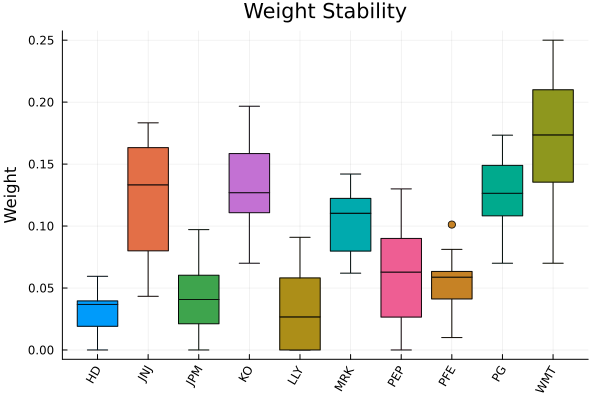

In [37]:
plot_ptf_cumulative_returns(idx_tn_walkforward_pred)
plot_turnover(idx_tn_walkforward_pred)
plot_weight_stability(idx_tn_walkforward_pred)

#### 2.3.2 DateWalkForward

The `DateWalkForward` estimator is similar to the `IndexWalkForward` estimator, but it allows us to specify the training and test periods in terms of dates. This can be useful if we want to align our training and test sets with specific calendar periods, such as fiscal years or quarters.

The `Dates` module provides a large amount of functionality to manipulate dates, but we will keep it simple. For this we will define an adjuster function that takes a date range generates a new one made up only of the last day of the month.

In [38]:
function ldm(x)
    val = lastdayofmonth.(x)
    while !isempty(val)
        if val[end] > x[end]
            val = val[1:(end - 1)]
        else
            break
        end
    end
    return val
end;

This estimator can take a few options, the first argument can also be a date period or compound period, but if we leave it as an integer it will take on that many periods. The second argument is always an integer and is the value of that many periods. Combining both gives us a fully determined mixture of training and test set lengths as both can be set to an arbitrarily defined training and testing period.

To keep it simple, we will keep the period unit the same for both. We will again train for a year and test for a quarter, but the dates will now align with the end of calendar months. The date boundaries are determined by searching for the last date in the timestamps less than a value in the date boundary. If the date of the timestamp is not found in the date range, the `previous` flag is used to determine whether to take the last date found (previous = true), or the next available date is used (previous = false). This means that in order to guarantee alignment of the first date of each test set with the last day of the month we need to set `previous` to true.

In [39]:
date_walk_forward = DateWalkForward(12, 3; period = Month(1), adjuster = ldm,
                                    previous = true)

DateWalkForward
     train_size ┼ Int64: 12
      test_size ┼ Int64: 3
         period ┼ Month: Month(1)
  period_offset ┼ nothing
    purged_size ┼ Int64: 0
       adjuster ┼ typeof(Main.var"##506".ldm): Main.var"##506".ldm
       previous ┼ Bool: true
   expand_train ┼ Bool: false
    reduce_test ┴ Bool: false


We can see what the splits look like.

In [40]:
date_walk_forward_res = split(date_walk_forward, rd)
show(date_walk_forward_res.train_idx)
show(date_walk_forward_res.test_idx)

UnitRange{Int64}[3:253, 64:314, 128:377, 191:441, 254:505, 315:567, 378:630, 442:694, 506:758, 568:819, 631:882, 695:946, 759:1010, 820:1072, 883:1134]UnitRange{Int64}[254:314, 315:377, 378:441, 442:505, 506:567, 568:630, 631:694, 695:758, 759:819, 820:882, 883:946, 947:1010, 1011:1072, 1073:1134, 1135:1198]

We will once more use the turnover constraint, but with this new cross validation method.

In [41]:
date_tn_walkforward_pred = cross_val_predict(mr, rd, date_walk_forward)

┌ Info: Running walk forward sequentially because the optimiser must either use the previous optimisation's weights (needs_previous_weights(opt) == true), and/or is time dependent (is_time_dependent(opt) == false). This is because somewhere within the optimisation estimator is contained at least one of the following:
│ 	- Turnover and/or TurnoverEstimator,
│ 	- WeightsTracking,
│ 	- TurnoverRiskMeasure,
│ 	- custom constraints which use asset weights,
│ 	- custom objective penalties which use asset weights.
│ 	- Or there is a time dependent constraint or objective penalty.
└ To enable parallel processing please either mark the weights as fixed or remove the offending component(s).


MultiPeriodPredictionResult
  pred ┼ 15-element Vector{PredictionResult}
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
       │ PredictionResult ⋯
   mrd ┼ PredictionReturnsResult
       │     nx ┼ 20-element SubArray{String, 1, Vector{String}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true}
       │      X ┼ 945-element Vector{Float64}
       │     nf ┼ nothing
       │      F ┼ nothing
       │     nb ┼ nothing
       │      B ┼ nothing
       │     ts ┼ 945-element Vector{Date}
       │     iv ┼ nothing
       │   ivpa ┴ nothing
    id ┴ nothing


We can see the evolution of the weights across the different splits. We can see how the weights change at most 2% per period.

In [42]:
pretty_table(hcat(DataFrame(:tickers => rd.nx),
                  DataFrame(reduce(hcat, getproperty.(date_tn_walkforward_pred.res, :w)),
                            Symbol.(1:15))); formatters = [resfmt])

┌─────────┬─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────
│ tickers │       1 │       2 │       3 │       4 │        5 │        6 │      ⋯
│  String │ Float64 │ Float64 │ Float64 │ Float64 │  Float64 │  Float64 │  Flo ⋯
├─────────┼─────────┼─────────┼─────────┼─────────┼──────────┼──────────┼───────
│    AAPL │   3.0 % │   1.0 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     AMD │   3.0 % │   1.0 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     BAC │   3.0 % │ 1.388 % │   0.0 % │   0.0 % │    0.0 % │    0.0 % │    0 ⋯
│     BBY │   3.0 % │ 2.859 % │ 4.005 % │ 2.005 % │  0.005 % │    0.0 % │    0 ⋯
│     CVX │   3.0 % │  4.56 % │ 3.364 % │ 5.364 % │  7.364 % │  5.364 % │  3.3 ⋯
│      GE │ 4.296 % │  2.36 % │ 0.788 % │ 0.688 % │    0.0 % │    0.0 % │    0 ⋯
│      HD │   3.0 % │ 4.999 % │ 5.964 % │ 3.965 % │  5.964 % │  3.965 % │  1.9 ⋯
│     JNJ │   7.0 % │ 5.998 % │ 4.248 % │ 6.247 % │  8.247 % │ 10.247 % │ 12.2 ⋯
│     JPM │ 5.704 % │ 7.704 

Calendar-aligned walk-forward: cumulative returns and turnover across month-end rebalancing dates.

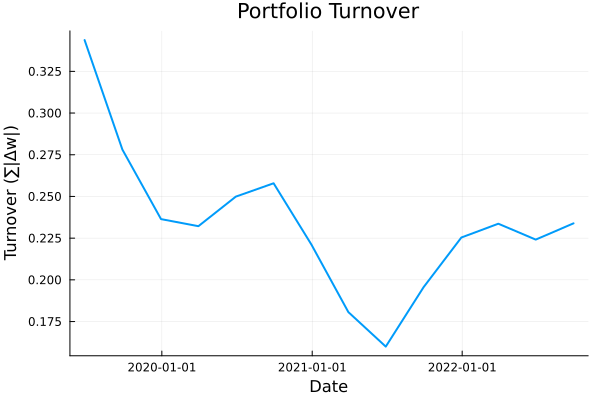

In [43]:
plot_ptf_cumulative_returns(date_tn_walkforward_pred)
plot_turnover(date_tn_walkforward_pred)

The splits are different to the index walkforward method, so the weights are also different, but we can see there's not too much variation. That's because the training periods are roughly the same. However, the turnover constraint also helps in stabilising the weights.

There is another cross validation method called `MultipleRandomised` which uses a walk forward estimator, but also randomly samples the asset universe. Since it is more complex to analyse and understand, we will cover it in a future example.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*